# Redes convolucionales: aprender patrones locales en imágenes

> Cómo una red convolucional (CNN) procesa una imagen: filtros que se deslizan por ella, mapas de características, *stride*, *padding* y *pooling*. Por qué necesita muchos menos parámetros que una red densa y rinde mucho más con imágenes, cómo se construye y entrena una en PyTorch con CIFAR-10 y qué errores de formas y dimensiones son los más habituales.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · [Entrenamiento y regularización](02-entrenamiento-y-regularizacion.ipynb) · **Relacionado:** [Transfer learning](04-transfer-learning.ipynb) · [Autoencoders](05-autoencoders.ipynb)

## 1. Idea clave

Una imagen es una cuadrícula de píxeles en la que **lo que importa es local** (un borde, una esquina, una textura) y **puede aparecer en cualquier sitio**. Una red densa aplana la imagen y trata cada píxel como una variable independiente: necesita muchísimos parámetros y no aprovecha que los vecinos están relacionados. Una **red convolucional** (*convolutional neural network*, CNN) sustituye las capas densas por **convoluciones**: pequeños filtros (por ejemplo de $3\times3$) que se deslizan por toda la imagen con los **mismos pesos** y detectan un patrón allí donde aparezca. Apilando capas se pasa de bordes a texturas, partes de objetos y objetos.

Se usan en clasificación, detección y segmentación de imágenes, y también con vídeo, audio o secuencias. Con datos sin estructura espacial (tablas) no tienen sentido; con muy pocos datos conviene partir de un modelo ya entrenado ([*transfer learning*](04-transfer-learning.ipynb)).

## 2. Conceptos importantes

### 2.1. Por qué no basta una red densa

Una imagen RGB de $32\times32$ tiene $32\cdot32\cdot3=3\,072$ valores; una de $224\times224$, 150 528. Una primera capa densa de 512 neuronas ya tiene 1,6 millones de parámetros con la primera y 77 millones con la segunda, y aun así no sabe que dos píxeles contiguos están relacionados ni que un gato es un gato esté en la esquina o en el centro. La convolución impone dos ideas: **conexiones locales** (cada neurona mira un trozo pequeño de la imagen) y **pesos compartidos** (el mismo filtro se aplica en todas las posiciones).

### 2.2. La convolución

Un **filtro** (*kernel*) $K$ de tamaño $k\times k$ se desliza por la imagen $I$ y, en cada posición, calcula la suma de productos entre el filtro y el trozo de imagen que cubre:

$$
(I\star K)(i,j)=\sum_{m=0}^{k-1}\sum_{n=0}^{k-1}I(i+m,\,j+n)\,K(m,n).
$$

(En rigor es una *correlación cruzada*; las librerías la llaman convolución.) El resultado es un **mapa de características** (*feature map*) que indica cuánto aparece el patrón del filtro en cada posición. Un filtro como $\begin{pmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{pmatrix}$ responde a bordes verticales. En una CNN **los valores de los filtros no se fijan a mano: se aprenden** con retropropagación.

Con imágenes de varios canales ($C_{\text{ent}}$, p. ej. 3 de RGB) cada filtro es un cubo $k\times k\times C_{\text{ent}}$ que suma sobre todos los canales; una capa con $C_{\text{sal}}$ filtros produce $C_{\text{sal}}$ mapas. Sus parámetros son

$$
\underbrace{(k^2\,C_{\text{ent}}+1)}_{\text{un filtro + sesgo}}\,C_{\text{sal}},
$$

independientes del tamaño de la imagen. Por ejemplo, 32 filtros de $3\times3$ sobre una imagen RGB: $(9\cdot3+1)\cdot32=896$ parámetros, sea la imagen de $32\times32$ o de $1000\times1000$.

### 2.3. *Padding* y *stride*

- **Relleno** (*padding*, $p$): se añaden $p$ píxeles (ceros) alrededor de la imagen para que los bordes se procesen igual y no encoja el tamaño. Con $k=3$ y $p=1$ el mapa conserva el tamaño.
- **Paso** (*stride*, $s$): cuántos píxeles se desplaza el filtro entre posiciones; con $s=2$ el mapa se reduce a la mitad.

Para una entrada de lado $n$, el lado de la salida es

$$
\left\lfloor\frac{n+2p-k}{s}\right\rfloor+1.
$$

### 2.4. *Pooling*

Reduce el tamaño de los mapas resumiendo regiones pequeñas: **max pooling** conserva el valor máximo de cada región (típicamente $2\times2$ con paso 2, que divide por la mitad el lado) y **average pooling** su media. Aporta cierta invariancia a pequeños desplazamientos, reduce el coste y hace que las capas siguientes vean regiones más grandes de la imagen. No tiene parámetros que aprender.

### 2.5. Propiedades clave

- **Parámetros compartidos**: pocos parámetros y mismo detector en toda la imagen.
- **Equivarianza a la traslación**: si el objeto se desplaza, su mapa de características se desplaza igual (el *pooling* añade algo de invariancia).
- **Campo receptivo**: la región de la imagen original que influye en una neurona. Dos convoluciones $3\times3$ seguidas ven $5\times5$; con *pooling* crece más rápido. Las capas profundas ven regiones grandes.
- **Jerarquía de características**: las primeras capas detectan bordes y colores, las intermedias texturas y partes, las últimas objetos completos.

### 2.6. Arquitectura típica

Se repiten **bloques** (convolución + activación + *pooling*, a veces con normalización por lotes), donde el tamaño espacial baja y el número de canales sube, y se termina con un bloque de **clasificación**: o se aplanan los mapas (*flatten*) y se pasan por capas densas, o se hace **promedio global** (*global average pooling*, GAP: la media de cada mapa) y una sola capa lineal. El GAP tiene muchos menos parámetros y no depende del tamaño de la imagen, a costa de algo de capacidad. En PyTorch las imágenes son tensores de forma `(lote, canales, alto, ancho)`.

## 3. Código

Usamos **CIFAR-10**: 60 000 imágenes en color de $32\times32$ píxeles de 10 clases (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión), 50 000 de entrenamiento y 10 000 de test. Dejamos 5 000 del entrenamiento para validación. Los píxeles (enteros de 0 a 255) se pasan a $[0,1]$ y se **estandarizan por canal** con la media y la desviación típica del entrenamiento.

In [1]:
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True             # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Datos

entrenamiento (45000, 3, 32, 32), validación (5000, 3, 32, 32), test (10000, 3, 32, 32)
media por canal: [0.491 0.482 0.447] | desviación por canal: [0.247 0.243 0.262]


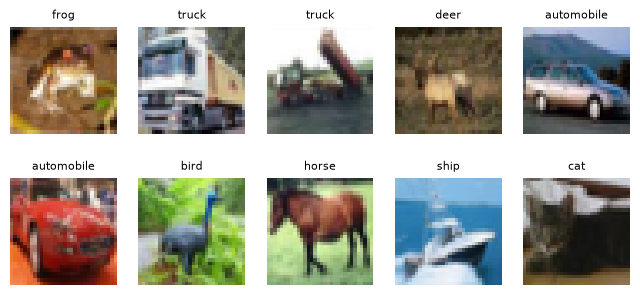

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.CIFAR10("data", train=True, download=True)
    prueba = datasets.CIFAR10("data", train=False, download=True)
clases = entrenamiento.classes

X = torch.tensor(entrenamiento.data).permute(0, 3, 1, 2).float().div(255)    # (N, 32, 32, 3) -> (N, 3, 32, 32)
y = torch.tensor(entrenamiento.targets)
X_test = torch.tensor(prueba.data).permute(0, 3, 1, 2).float().div(255)
y_test = torch.tensor(prueba.targets)
media, desv = X.mean((0, 2, 3), keepdim=True), X.std((0, 2, 3), keepdim=True)
X, X_test = (X - media) / desv, (X_test - media) / desv

orden = torch.randperm(len(X), generator=torch.Generator().manual_seed(42))
X_train, y_train = X[orden[:45000]], y[orden[:45000]]
X_val, y_val = X[orden[45000:]], y[orden[45000:]]
print(f"entrenamiento {tuple(X_train.shape)}, validación {tuple(X_val.shape)}, test {tuple(X_test.shape)}")
print("media por canal:", media.flatten().numpy().round(3), "| desviación por canal:", desv.flatten().numpy().round(3))

fig, axes = plt.subplots(2, 5, figsize=(8, 3.6))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(entrenamiento.data[i])
    ax.set_title(clases[entrenamiento.targets[i]], fontsize=8)
    ax.axis("off")
plt.show()

### 3.2. La convolución a mano

Comprobamos la fórmula de 2.2 con un bucle sobre una imagen $5\times5$ y la comparamos con `F.conv2d`. Después comprobamos la fórmula del tamaño de salida de 2.3 para varias combinaciones de relleno y paso.

In [3]:
imagen = torch.arange(25.0).reshape(1, 1, 5, 5)
filtro = torch.tensor([[1.0, 0.0, -1.0], [2.0, 0.0, -2.0], [1.0, 0.0, -1.0]]).reshape(1, 1, 3, 3)

a_mano = torch.zeros(3, 3)
for i in range(3):
    for j in range(3):
        a_mano[i, j] = (imagen[0, 0, i:i + 3, j:j + 3] * filtro[0, 0]).sum()
print("Máxima diferencia entre el bucle y F.conv2d:", (a_mano - F.conv2d(imagen, filtro)[0, 0]).abs().max().item())

filas = []
for k, p, s in [(3, 0, 1), (3, 1, 1), (3, 1, 2), (5, 2, 1), (5, 0, 2)]:
    real = nn.Conv2d(1, 1, kernel_size=k, padding=p, stride=s)(torch.zeros(1, 1, 32, 32)).shape[-1]
    filas.append({"filtro k": k, "relleno p": p, "paso s": s, "lado según la fórmula": (32 + 2 * p - k) // s + 1, "lado real": real})
pd.DataFrame(filas)

Máxima diferencia entre el bucle y F.conv2d: 0.0


,filtro k,relleno p,paso s,lado según la fórmula,lado real
0,3,0,1,30,30
1,3,1,1,32,32
2,3,1,2,16,16
3,5,2,1,32,32
4,5,0,2,14,14


Coinciden. Veamos qué hacen filtros de borde sobre una imagen real (un automóvil de CIFAR-10, en escala de grises): los dos filtros de Sobel (horizontal y vertical) responden a los bordes de cada orientación, y su combinación da el contorno.

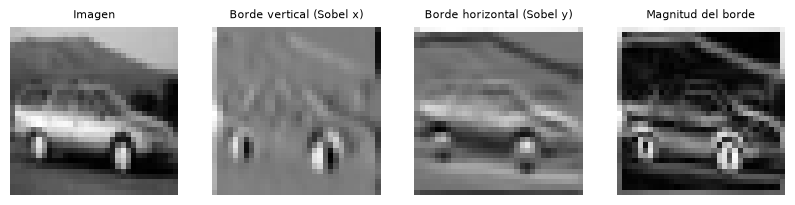

In [4]:
i_coche = int((y == clases.index("automobile")).nonzero()[0])
gris = (X[i_coche] * desv[0] + media[0]).mean(0)                # se deshace la estandarización y se promedian los canales
sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])
sobel_y = sobel_x.T
gx = F.conv2d(gris[None, None], sobel_x[None, None], padding=1)[0, 0]
gy = F.conv2d(gris[None, None], sobel_y[None, None], padding=1)[0, 0]

fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for ax, img, titulo in zip(axes, [gris, gx, gy, (gx ** 2 + gy ** 2).sqrt()], ["Imagen", "Borde vertical (Sobel x)", "Borde horizontal (Sobel y)", "Magnitud del borde"]):
    ax.imshow(img, cmap="gray"); ax.set_title(titulo, fontsize=8); ax.axis("off")
plt.show()

Una CNN hace esto mismo, pero **aprende** los valores de los filtros que mejor sirven para clasificar, en vez de fijarlos a mano.

### 3.3. Entrenamiento: una red densa y tres variantes convolucionales

Un bucle de entrenamiento como el de [la red densa](01-redes-neuronales-densas.ipynb), con 15 épocas y Adam, que además permite aplicar **aumento de datos** (volteo horizontal y recorte aleatorio con relleno de 4 píxeles, aplicado por lotes y solo al entrenamiento) y devuelve la pérdida y la exactitud en validación de cada época. Comparamos cuatro modelos:

1. **MLP**: dos capas ocultas de 512 neuronas sobre la imagen aplanada.
2. **CNN con *flatten***: tres bloques (convolución $3\times3$ + ReLU + *max pooling*) de 32, 64 y 128 filtros, y una capa densa de 128.
3. **CNN con GAP**: los mismos tres bloques y, en lugar de la capa densa, promedio global y una capa lineal.
4. **CNN con normalización por lotes, *dropout* y aumento de datos**: como la 2, con normalización por lotes en cada bloque, *dropout* de 0,3 antes de la salida y aumento de datos.

In [5]:
def evaluar(modelo, X_, y_):
    modelo.eval()
    perdida, aciertos = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X_), 1000):
            logits = modelo(X_[i:i + 1000].to(device))
            perdida += F.cross_entropy(logits, y_[i:i + 1000].to(device), reduction="sum").item()
            aciertos += (logits.argmax(1).cpu() == y_[i:i + 1000]).sum().item()
    return perdida / len(X_), aciertos / len(X_)

def aumentar(xb):                                         # volteo horizontal + recorte aleatorio con relleno de 4 px
    volteo = torch.rand(len(xb), device=xb.device) < 0.5
    xb = torch.where(volteo[:, None, None, None], xb.flip(3), xb)
    relleno = F.pad(xb, (4, 4, 4, 4), mode="reflect")
    i, j = np.random.randint(0, 9, 2)
    return relleno[:, :, i:i + 32, j:j + 32]

def entrenar(modelo, epocas=15, lr=1e-3, lote=128, aumento=False, semilla=0):
    modelo.to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    cargador = DataLoader(TensorDataset(X_train, y_train), batch_size=lote, shuffle=True, generator=torch.Generator().manual_seed(semilla))
    historial = []
    for _ in range(epocas):
        modelo.train()
        for xb, yb in cargador:
            xb, yb = xb.to(device), yb.to(device)
            if aumento:
                xb = aumentar(xb)
            opt.zero_grad()
            F.cross_entropy(modelo(xb), yb).backward()
            opt.step()
        val_perdida, val_exactitud = evaluar(modelo, X_val, y_val)
        historial.append({"pérdida validación": val_perdida, "exactitud validación": val_exactitud})
    return pd.DataFrame(historial, index=range(1, epocas + 1))

def bloque(n_in, n_out, bn=False):
    return [nn.Conv2d(n_in, n_out, 3, padding=1)] + ([nn.BatchNorm2d(n_out)] if bn else []) + [nn.ReLU(), nn.MaxPool2d(2)]

modelos = {
    "MLP": nn.Sequential(nn.Flatten(), nn.Linear(3072, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 10)),
    "CNN con flatten": nn.Sequential(*bloque(3, 32), *bloque(32, 64), *bloque(64, 128), nn.Flatten(), nn.Linear(128 * 4 * 4, 128), nn.ReLU(), nn.Linear(128, 10)),
    "CNN con GAP": nn.Sequential(*bloque(3, 32), *bloque(32, 64), *bloque(64, 128), nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 10)),
    "CNN + BN + dropout + aumento": nn.Sequential(*bloque(3, 32, True), *bloque(32, 64, True), *bloque(64, 128, True), nn.Flatten(),
                                                  nn.Linear(128 * 4 * 4, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 10)),
}
historiales, filas = {}, {}
for nombre, modelo in modelos.items():
    torch.manual_seed(0)
    np.random.seed(0)                                     # semilla del recorte aleatorio
    for capa in modelo.modules():                         # reinicia los pesos con la semilla fijada
        if hasattr(capa, "reset_parameters"):
            capa.reset_parameters()
    h = entrenar(modelo, aumento=nombre.endswith("aumento"))
    historiales[nombre] = h
    filas[nombre] = {"parámetros": sum(p.numel() for p in modelo.parameters()), "exactitud validación (época 15)": h["exactitud validación"].iloc[-1],
                     "pérdida validación (mínima)": h["pérdida validación"].min(), "pérdida validación (época 15)": h["pérdida validación"].iloc[-1]}
resultados = pd.DataFrame(filas).T
resultados["parámetros"] = resultados["parámetros"].astype(int)
resultados.round(3)

,parámetros,exactitud validación (época 15),pérdida validación (mínima),pérdida validación (época 15)
MLP,1841162,0.511,1.405,2.134
CNN con flatten,356810,0.745,0.749,1.211
CNN con GAP,94538,0.713,0.821,0.821
CNN + BN + dropout + aumento,357258,0.793,0.575,0.575


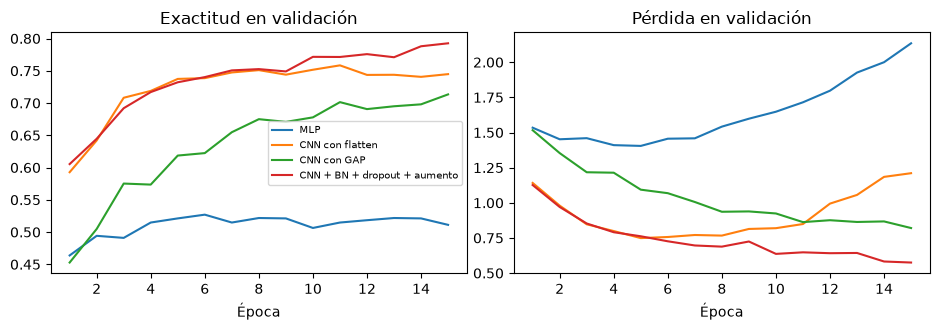

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for nombre, h in historiales.items():
    h["exactitud validación"].plot(ax=axes[0], label=nombre)
    h["pérdida validación"].plot(ax=axes[1], label=nombre)
axes[0].set_title("Exactitud en validación"); axes[1].set_title("Pérdida en validación")
for ax in axes:
    ax.set_xlabel("Época")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

- El **MLP** (1,84 millones de parámetros) se queda en ≈ 0,51 de exactitud en validación (alcanza 0,53 en la época 6) y sobreajusta pronto: la pérdida de validación sube de 1,41 a 2,13.
- La **CNN con *flatten*** tiene **5 veces menos parámetros** (357 mil) y llega a ≈ 0,745: la estructura espacial vale mucho más que los parámetros. También sobreajusta (su pérdida mínima de 0,749 sube hasta 1,21).
- La **CNN con GAP** tiene solo 94 538 parámetros (casi 4 veces menos que la anterior, y 20 veces menos que el MLP) y llega a ≈ 0,71: pierde unos 3 puntos de exactitud (0,713 frente a 0,745) a cambio de ahorrar el 74 % de los parámetros, y su pérdida no sobreajusta en estas 15 épocas (0,821 al final).
- La **CNN con normalización por lotes, *dropout* y aumento** es la mejor (≈ 0,79 de exactitud, y la pérdida de validación baja hasta 0,575 sin sobreajustar): la regularización de [la red densa](02-entrenamiento-y-regularizacion.ipynb) sigue valiendo aquí y es más importante cuanto mayor es la capacidad. Las curvas de exactitud suben a trompicones de una época a otra, así que conviene fijarse en la tendencia y en la pérdida.

### 3.4. Qué ha aprendido la red

Con la CNN mejor evaluamos en test (una sola vez) y miramos la exactitud por clase. Después representamos los 32 filtros de la primera capa y los mapas de características que producen sobre una imagen.

In [7]:
mejor = modelos["CNN + BN + dropout + aumento"]
test_perdida, test_exactitud = evaluar(mejor, X_test, y_test)
print(f"Test (una sola vez): exactitud {test_exactitud:.3f}, pérdida {test_perdida:.3f}")

mejor.eval()
with torch.no_grad():
    predicho = mejor(X_test.to(device)).argmax(1).cpu()
por_clase = pd.Series({c: (predicho[y_test == k] == k).float().mean().item() for k, c in enumerate(clases)}).sort_values()
print(por_clase.round(3).to_string())

Test (una sola vez): exactitud 0.799, pérdida 0.581
cat           0.517
bird          0.697
dog           0.703
deer          0.802
truck         0.834
horse         0.863
ship          0.866
airplane      0.874
frog          0.893
automobile    0.942


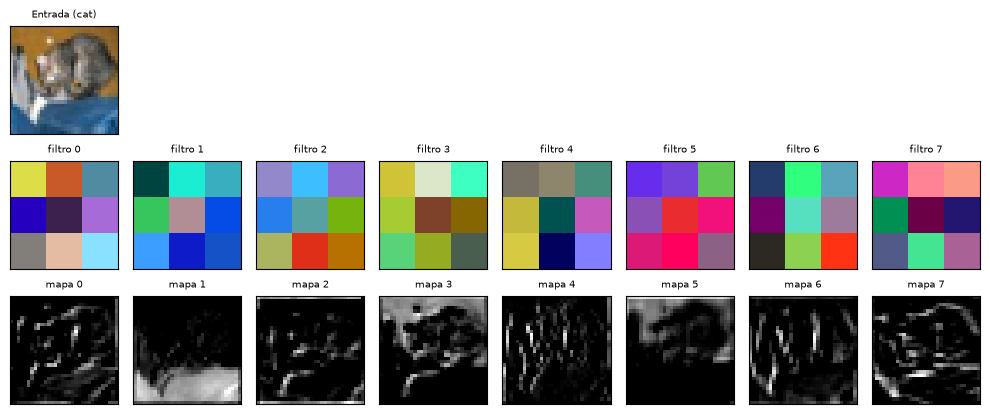

In [8]:
filtros = mejor[0].weight.detach().cpu()                  # (32, 3, 3, 3): 32 filtros RGB de 3x3
filtros = (filtros - filtros.amin((1, 2, 3), keepdim=True)) / (filtros.amax((1, 2, 3), keepdim=True) - filtros.amin((1, 2, 3), keepdim=True))
imagen = X_test[0:1].to(device)
with torch.no_grad():
    mapas = mejor[:3](imagen)[0].cpu()                    # conv + BN + ReLU del primer bloque: (32, 32, 32)

fig, axes = plt.subplots(3, 8, figsize=(10, 4.2))
axes[0, 0].imshow((X_test[0] * desv[0] + media[0]).permute(1, 2, 0).clamp(0, 1)); axes[0, 0].set_title(f"Entrada ({clases[y_test[0]]})", fontsize=7)
for ax in axes[0, 1:]:
    ax.axis("off")
for k in range(8):
    axes[1, k].imshow(filtros[k].permute(1, 2, 0)); axes[1, k].set_title(f"filtro {k}", fontsize=7)
    axes[2, k].imshow(mapas[k], cmap="gray"); axes[2, k].set_title(f"mapa {k}", fontsize=7)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

En test la CNN obtiene una exactitud de 0,799. Por clase, la mejor es el **automóvil** (0,94), seguida de rana (0,89), avión (0,87) y barco (0,87); la peor, con diferencia, el **gato** (0,52), seguido del pájaro y el perro (≈ 0,70): clases con mucha variación de pose y fondo y, en el caso del gato, parecidas al perro. Los filtros de la primera capa son sobre todo **detectores de color** y de contraste entre colores (cada uno es un cubo $3\times3\times3$ que se dibuja como un mosaico RGB), y los mapas de características resaltan contornos y regiones de la imagen: parecido a lo que hicimos a mano con Sobel, pero aprendido.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| `nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | Entradas y salidas, tamaño del filtro, paso y relleno | `kernel_size=3` y `padding=1` (conserva el tamaño); `stride=2` para reducir |
| Número de filtros por capa | Capacidad de cada capa | 32 → 64 → 128 …: se duplica al reducir a la mitad el lado |
| `nn.MaxPool2d(2)` | Reducción del lado a la mitad | Tras cada 1–2 convoluciones; no tiene parámetros |
| `nn.AdaptiveAvgPool2d(1)` | Promedio global (GAP) | Sustituye a *flatten* + densas si hay que ahorrar parámetros o la entrada varía de tamaño |
| `nn.BatchNorm2d` | Normaliza canales por lote | Tras la convolución y antes de la activación; recuerda `model.eval()` |
| Aumento de datos | Variabilidad | Volteo y recorte para imágenes naturales; solo en entrenamiento |
| Normalización de entradas | Escala de los píxeles | $[0,1]$ y luego media/desviación por canal del entrenamiento |

### 4.2. Errores comunes

- **Olvidar el `Flatten`** entre las capas convolucionales y las densas: da un error de dimensiones. Demo a continuación.
- **Definir `forward` dentro de `__init__`** (un error de sangrado): la clase no tiene `forward` y falla al llamarla. Demo a continuación.
- **Calcular mal el número de entradas de la capa densa** tras los bloques: con 3 bloques de *pooling* un lado 32 pasa a 4, así que la capa recibe $128\cdot4\cdot4=2\,048$ valores. Si cambias el tamaño de la imagen, la fórmula de 2.3 te dice el nuevo valor (o usa GAP, que no depende de ello).
- **Confundir el orden de las dimensiones.** PyTorch espera `(N, C, H, W)`; Matplotlib espera `(H, W, C)` (hay que `permute(1, 2, 0)` para dibujar, 3.1 y 3.4).
- **Mirar solo el rango.** Si las imágenes entran como enteros de 0 a 255 en lugar de $[0,1]$ y estandarizadas, el entrenamiento es lento o inestable. Comprueba el valor mínimo y máximo de un lote antes de entrenar.
- **Poner una `softmax` al final del modelo y usar `CrossEntropyLoss`** (doble softmax; véase [la red densa](01-redes-neuronales-densas.ipynb)).
- **Aplicar el aumento de datos a validación o test.**
- **Flatten con muchos canales:** el número de parámetros de la primera capa densa se dispara (3.3: la CNN con *flatten* tiene casi 4 veces más parámetros que la de GAP, la mayoría en esa capa). Con imágenes grandes, usa GAP o más *pooling*.
- **Evaluar sin `model.eval()`** con normalización por lotes o *dropout*.
- **Fiarse de una época.** Las curvas de validación son ruidosas; usa la pérdida y la parada temprana ([regularización](02-entrenamiento-y-regularizacion.ipynb)).

#### Demo: los dos errores de código más habituales

In [9]:
# 1. Sin Flatten entre la parte convolucional y la capa lineal
sin_flatten = nn.Sequential(nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Linear(8, 10))
try:
    sin_flatten(torch.zeros(2, 3, 32, 32))
except RuntimeError as error:
    print("Sin Flatten ->", str(error)[:110])

# 2. forward definido (por un error de sangrado) dentro de __init__
class RedMal(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 8, 3)

        def forward(self, x):
            return self.conv(x)

try:
    RedMal()(torch.zeros(1, 3, 32, 32))
except NotImplementedError as error:
    print("forward dentro de __init__ ->", str(error)[:90])

Sin Flatten -> mat1 and mat2 shapes cannot be multiplied (16x1 and 8x10)
forward dentro de __init__ -> Module [RedMal] is missing the required "forward" function


En el primero, `Linear(8, 10)` recibe un tensor de 4 dimensiones `(2, 8, 1, 1)` y falla al multiplicar matrices; basta con añadir `nn.Flatten()` antes. En el segundo, `forward` quedó como una función interna de `__init__` y la clase no lo tiene, así que PyTorch avisa de que falta.

## 5. Comparación con métodos relacionados

| Modelo | Aprovecha la estructura espacial | Parámetros | Datos que necesita | Cuándo usarlo |
|---|---|---|---|---|
| **[MLP](01-redes-neuronales-densas.ipynb)** sobre píxeles aplanados | No | Muchos (crecen con la imagen) | Muchos | Línea base; datos sin estructura espacial |
| **CNN desde cero** | Sí (conexiones locales, pesos compartidos) | Pocos | Muchos (decenas de miles de imágenes) | Imágenes propias con bastantes datos |
| **CNN con GAP** | Sí | Aún menos | Muchos | Cuando se busca un modelo pequeño o con entrada de tamaño variable |
| **[Transfer learning](04-transfer-learning.ipynb)** | Sí (parte de un modelo ya entrenado) | Muchos, pero la mayoría congelados | Pocos | Pocas imágenes: casi siempre la mejor opción |
| ***Vision transformer*** | Sí, de otra forma (atención) | Muchos | Muchísimos o preentrenado | Grandes volúmenes de datos ([transformers](07-atencion-y-transformers.ipynb)) |
| **Métodos clásicos** (HOG/SIFT + SVM o bosques) | A mano | Pocos | Pocos | Problemas pequeños; hoy superados en casi todo |

La elección habitual hoy: con pocas imágenes, *transfer learning*; con muchas y un dominio propio, una CNN profunda desde cero o ajustada.

## 6. Referencias

### Fuentes

- Krizhevsky, A. (2009). [*Learning multiple layers of features from tiny images*](https://www.cs.toronto.edu/~kriz/cifar.html). Informe técnico, Universidad de Toronto. Origen de CIFAR-10, descargado con [`torchvision.datasets.CIFAR10`](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).
- PyTorch: [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html), [`nn.AdaptiveAvgPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html), [`nn.BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) y [`F.conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.functional.conv2d.html).

### Para saber más

- LeCun, Y., Bottou, L., Bengio, Y. y Haffner, P. (1998). [«Gradient-based learning applied to document recognition»](https://doi.org/10.1109/5.726791). *Proceedings of the IEEE*, 86(11), 2278–2324. El artículo de LeNet-5: el origen de las redes convolucionales modernas.
- Dumoulin, V. y Visin, F. (2016). [*A guide to convolution arithmetic for deep learning*](https://arxiv.org/abs/1603.07285). arXiv:1603.07285. La referencia para entender tamaños de salida, *padding*, *stride* y convoluciones transpuestas.